In [1]:
import numpy as np
import matplotlib.pyplot as plt
from casacore.tables import table, taql
import matplotlib.pyplot as plt
import astropy.units as u

bandpass.shape=(288,)
bandpass_ft.shape=(2344,)
ft_freqs.shape=(2344,)
OVERSAMPLE=8.13888888888889
sinc.shape=(2344,)


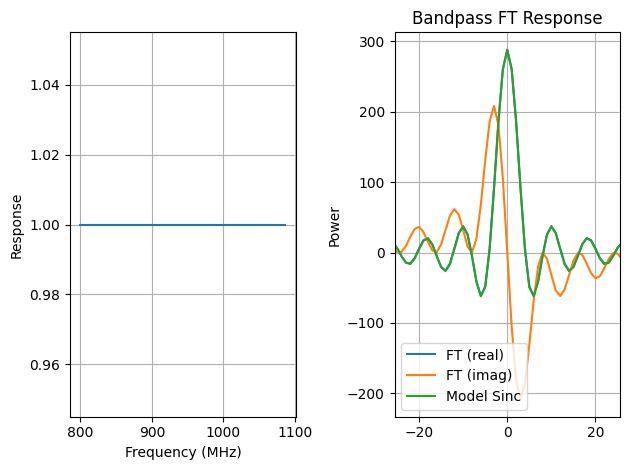

In [2]:
NCHAN = 288
NSAMPLE  = NCHAN + 2056
DIFF = NSAMPLE - NCHAN

bandpass = np.ones(NCHAN, dtype=complex)
obs_hz = (np.arange(NCHAN) + 800) * u.Hz
print(f"{bandpass.shape=}")


bandpass_ft = np.fft.fftshift(
    np.fft.fft(bandpass, n=NSAMPLE)
)
ft_freqs = np.fft.fftfreq(
    NSAMPLE, 
    d=(obs_hz[2]-obs_hz[1]).decompose().value,
)
print(f"{bandpass_ft.shape=}")
print(f"{ft_freqs.shape=}")

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(obs_hz, np.abs(bandpass))
ax1.set(
    xlabel="Frequency (MHz)",
    ylabel="Response"
)
ax1.grid()

OFFSET = 100
OVERSAMPLE = NSAMPLE / NCHAN
print(f"{OVERSAMPLE=}")
x_sinc = (np.arange(NSAMPLE) - NSAMPLE/2)
sinc = np.sinc(x_sinc / OVERSAMPLE * 2)
sinc = sinc / np.max(sinc) * np.max(bandpass_ft.real)


ax2.plot(x_sinc, bandpass_ft.real, label="FT (real)")
ax2.plot(x_sinc, bandpass_ft.imag, label="FT (imag)")
ax2.plot(x_sinc, sinc, label="Model Sinc")

ax2.set(
    xlim=[-np.pi*OVERSAMPLE, np.pi*OVERSAMPLE],
    ylabel="Power",
    title="Bandpass FT Response"
)
ax2.grid()
ax2.legend()

fig.tight_layout()

print(f"{sinc.shape=}")

# I am OK with the peak of the imaginary not being 
# equal to the response of the model as the model is
# normalised to the max of the amplitude. The phase
# offset is the main worry I have at the moment



bandpass.shape=(288,)
bandpass_ft.shape=(1173,)
ft_freqs.shape=(2344,)
OVERSAMPLE=8.13888888888889
sinc.shape=(1173,)


/datasets/work/jones-storage/work/miniconda/miniforge3/envs/flint_main/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/datasets/work/jones-storage/work/miniconda/miniforge3/envs/flint_main/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


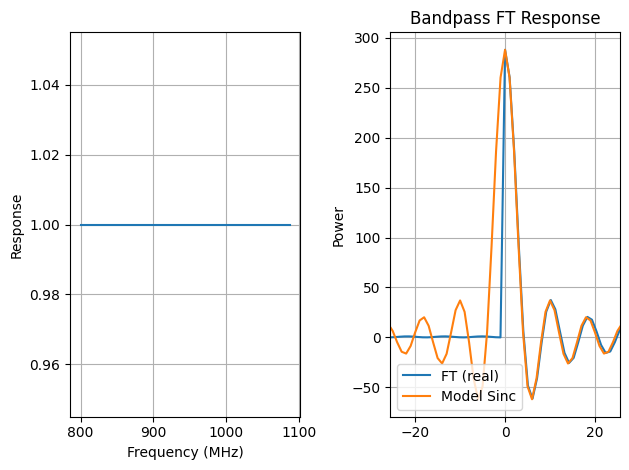

In [3]:
NCHAN = 288
NSAMPLE  = NCHAN + 2056
DIFF = NSAMPLE - NCHAN

bandpass = np.ones(NCHAN)
obs_hz = (np.arange(NCHAN) + 800) * u.Hz
print(f"{bandpass.shape=}")


bandpass_ft = np.fft.fftshift(
    np.fft.rfft(bandpass, n=NSAMPLE)
)
ft_freqs = np.fft.fftfreq(
    NSAMPLE, 
    d=(obs_hz[2]-obs_hz[1]).decompose().value,
)
print(f"{bandpass_ft.shape=}")
print(f"{ft_freqs.shape=}")

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(obs_hz, np.abs(bandpass))
ax1.set(
    xlabel="Frequency (MHz)",
    ylabel="Response"
)
ax1.grid()

OFFSET = 100
OVERSAMPLE = NSAMPLE / NCHAN
print(f"{OVERSAMPLE=}")
x_sinc = (np.arange(NSAMPLE//2 + 1) - NSAMPLE/4)
sinc = np.sinc(x_sinc / OVERSAMPLE * 2)
sinc = sinc / np.max(sinc) * np.max(bandpass_ft.real)


# ----------------------
# Why the scalinåg factors here.
# The extra 2 is to account for the real input into the rfft.
# as the number of samples appears to extend onto the positive
# bomain only. 
# ----------------------

ax2.plot(x_sinc/4/2*OVERSAMPLE, bandpass_ft, label="FT (real)")
ax2.plot(x_sinc, sinc, label="Model Sinc")

ax2.set(
    xlim=[-np.pi*OVERSAMPLE, np.pi*OVERSAMPLE],
    ylabel="Power",
    title="Bandpass FT Response"
)
ax2.grid()
ax2.legend()

fig.tight_layout()

print(f"{sinc.shape=}")



bandpass.shape=(288,)
bandpass_ft.shape=(1173,)
ft_freqs.shape=(2344,)
OVERSAMPLE=8.13888888888889


sinc.shape=(1173,)


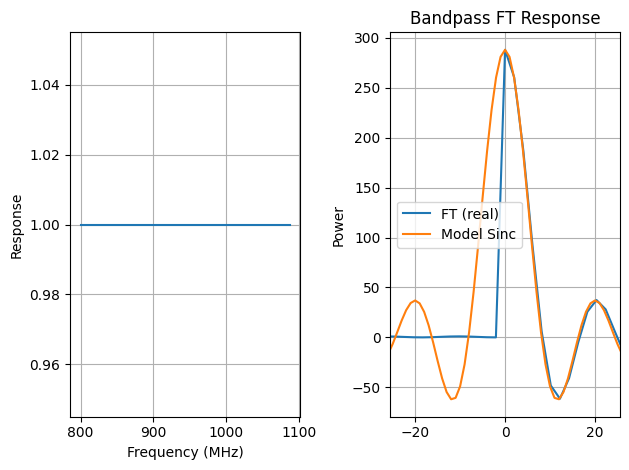

In [4]:
NCHAN = 288
NSAMPLE  = NCHAN + 2056
DIFF = NSAMPLE - NCHAN

bandpass = np.ones(NCHAN)
obs_hz = (np.arange(NCHAN) + 800) * u.Hz
print(f"{bandpass.shape=}")


bandpass_ft = np.fft.fftshift(
    np.fft.rfft(bandpass, n=NSAMPLE)
)
ft_freqs = np.fft.fftfreq(
    NSAMPLE, 
    d=(obs_hz[2]-obs_hz[1]).decompose().value,
)
print(f"{bandpass_ft.shape=}")
print(f"{ft_freqs.shape=}")

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(obs_hz, np.abs(bandpass))
ax1.set(
    xlabel="Frequency (MHz)",
    ylabel="Response"
)
ax1.grid()

OFFSET = 100
OVERSAMPLE = NSAMPLE / NCHAN
print(f"{OVERSAMPLE=}")
x_sinc = (np.arange(NSAMPLE//2 + 1) - NSAMPLE/4)
sinc = np.sinc(x_sinc / OVERSAMPLE)
sinc = sinc / np.max(sinc) * np.max(bandpass_ft.real)


# ----------------------
# Why the scalinåg factors here. 
# The divisor of 4 is still a little confusing to me.
# ----------------------

ax2.plot(x_sinc/4*OVERSAMPLE, bandpass_ft, label="FT (real)")
ax2.plot(x_sinc, sinc, label="Model Sinc")

ax2.set(
    xlim=[-np.pi*OVERSAMPLE, np.pi*OVERSAMPLE],
    ylabel="Power",
    title="Bandpass FT Response"
)
ax2.grid()
ax2.legend()

fig.tight_layout()

print(f"{sinc.shape=}")



[(-25.56907354171693, 25.56907354171693)]

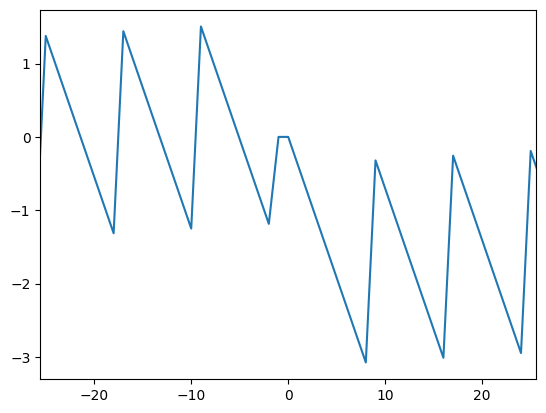

In [5]:
fig, ax = plt.subplots(1,1)

ax.plot(
    x_sinc, np.angle(bandpass_ft)
)
ax.set(
    xlim=[-np.pi*OVERSAMPLE, np.pi*OVERSAMPLE],
)


In [6]:



bandpass = np.ones(288, dtype=complex)

print(f"{bandpass.shape=}")

len_ft = 1000

ft = np.fft.fftshift(
    np.fft.fft(bandpass, n=len_ft)
)

ft_freqs = np.fft.fftshift(
        np.fft.fftfreq(
        len_ft
    )
)

fig, (ax1, ax2) = plt.subplots(1,2)

ax1.plot(bandpass)

ax2.plot(ft)
ax2.set(
    xlim=[475, 525]
)

import astropy.units as u

width = ft_freqs[-1]

T = 
print(f"{width=}")

sinc = np.sinc(
    ft_freqs
)


# fig, ax2 = plt.subplots(1,1)
a = width *np.linspace(-(len_ft)/2, (len_ft)/2, len_ft)
s = np.sinc(a)
s = s / np.max(s) * np.max(ft)
ax2.plot(s)

print(f"{a.shape=} {a[0]} {a[-1]}")



SyntaxError: invalid syntax (2457036118.py, line 30)

In [ ]:
np.fft.fftshift(
    np.fft.fftfreq(288*2)
)

array([-0.5       , -0.49826389, -0.49652778, -0.49479167, -0.49305556,
       -0.49131944, -0.48958333, -0.48784722, -0.48611111, -0.484375  ,
       -0.48263889, -0.48090278, -0.47916667, -0.47743056, -0.47569444,
       -0.47395833, -0.47222222, -0.47048611, -0.46875   , -0.46701389,
       -0.46527778, -0.46354167, -0.46180556, -0.46006944, -0.45833333,
       -0.45659722, -0.45486111, -0.453125  , -0.45138889, -0.44965278,
       -0.44791667, -0.44618056, -0.44444444, -0.44270833, -0.44097222,
       -0.43923611, -0.4375    , -0.43576389, -0.43402778, -0.43229167,
       -0.43055556, -0.42881944, -0.42708333, -0.42534722, -0.42361111,
       -0.421875  , -0.42013889, -0.41840278, -0.41666667, -0.41493056,
       -0.41319444, -0.41145833, -0.40972222, -0.40798611, -0.40625   ,
       -0.40451389, -0.40277778, -0.40104167, -0.39930556, -0.39756944,
       -0.39583333, -0.39409722, -0.39236111, -0.390625  , -0.38888889,
       -0.38715278, -0.38541667, -0.38368056, -0.38194444, -0.38